In [1]:
import pandas as pd

# Read the dataset
df = pd.read_csv(r"C:\Data\Fraud_Data.csv")


In [2]:
df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='str')

In [20]:
X = df.drop('class', axis=1)
y = df['class']

In [21]:
df_model = pd.get_dummies(df, columns=['source', 'browser', 'sex'], drop_first=True)

In [22]:
df_model.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,39,7.327584e+08,0,False,True,False,False,False,False,True
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,53,3.503114e+08,0,False,False,False,False,False,False,False
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,53,2.621474e+09,1,False,True,False,False,True,False,True
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,41,3.840542e+09,0,False,True,False,False,False,True,True
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,45,4.155831e+08,0,False,False,False,False,False,True,True


In [23]:
X = df_model.drop('class', axis=1)
y = df_model['class']

In [24]:
df.columns = df.columns.str.strip()

In [25]:
print(type(df))
print(df.columns.tolist())

<class 'pandas.DataFrame'>
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']


In [26]:
print("signup_time" in df.columns)

True


In [27]:
for c in df.columns:
    print(c, len(c))

user_id 7
signup_time 11
purchase_time 13
purchase_value 14
device_id 9
source 6
browser 7
sex 3
age 3
ip_address 10
class 5


In [28]:
print(len("signup_time"))

11


In [35]:
print(type(df))
print(df.columns.tolist())
print("signup_time" in df.columns)

for col in df.columns:
    print(repr(col))

<class 'pandas.DataFrame'>
['user_id', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']
False
'user_id'
'purchase_value'
'device_id'
'source'
'browser'
'sex'
'age'
'ip_address'
'class'


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["device_id"] = le.fit_transform(df["device_id"])

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.select_dtypes(include=['object', 'string']).columns.tolist())

['signup_time', 'purchase_time', 'device_id']


In [39]:
X = X.drop(columns=['device_id'])

In [40]:
print(X.columns.tolist())

['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'age', 'ip_address', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']


In [41]:
y = df['class']

In [42]:
X = df.drop(columns=['class', 'signup_time', 'purchase_time'], errors='ignore')

In [43]:
if 'device_id' in X.columns:
    device_freq = X['device_id'].value_counts()
    X['device_id_freq'] = X['device_id'].map(device_freq)
    X = X.drop(columns=['device_id'])

In [53]:
X = pd.get_dummies(X, drop_first=True)

In [54]:
print(X.dtypes)
print(X.columns)

user_id              int64
purchase_value       int64
age                  int64
ip_address         float64
device_id_freq       int64
source_Direct         bool
source_SEO            bool
browser_FireFox       bool
browser_IE            bool
browser_Opera         bool
browser_Safari        bool
sex_M                 bool
dtype: object
Index(['user_id', 'purchase_value', 'age', 'ip_address', 'device_id_freq',
       'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE',
       'browser_Opera', 'browser_Safari', 'sex_M'],
      dtype='str')


In [49]:
X = pd.get_dummies(X, drop_first=True)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [52]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
4,device_id_freq,0.493750
0,user_id,0.170691
3,ip_address,0.142491
1,purchase_value,0.088087
2,age,0.073165
11,sex_M,0.008199
8,browser_IE,0.004899
10,browser_Safari,0.004799
7,browser_FireFox,0.004527
6,source_SEO,0.004490


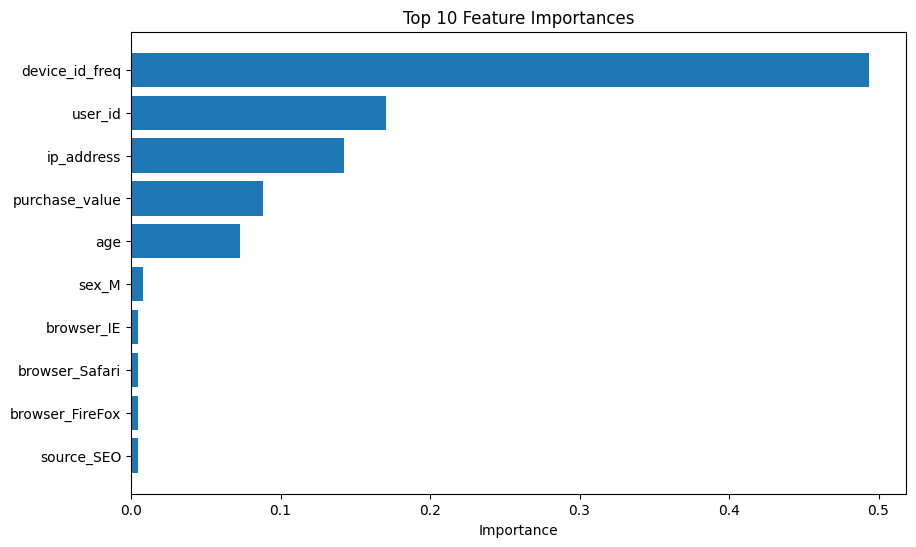

In [53]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

In [63]:
X = df.drop(columns=['class'], errors='ignore')
y = df['class']

In [64]:
X = pd.get_dummies(X, drop_first=True)

In [69]:
import shap

X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

In [70]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

In [95]:
# build explainer
explainer = shap.TreeExplainer(best_model)

In [96]:
X_sample = X_test.sample(100, random_state=42)

shap_values = explainer(X_sample)

In [97]:
print(shap_values.values.shape)
print(X_sample.shape)

(100, 12, 2)
(100, 12)


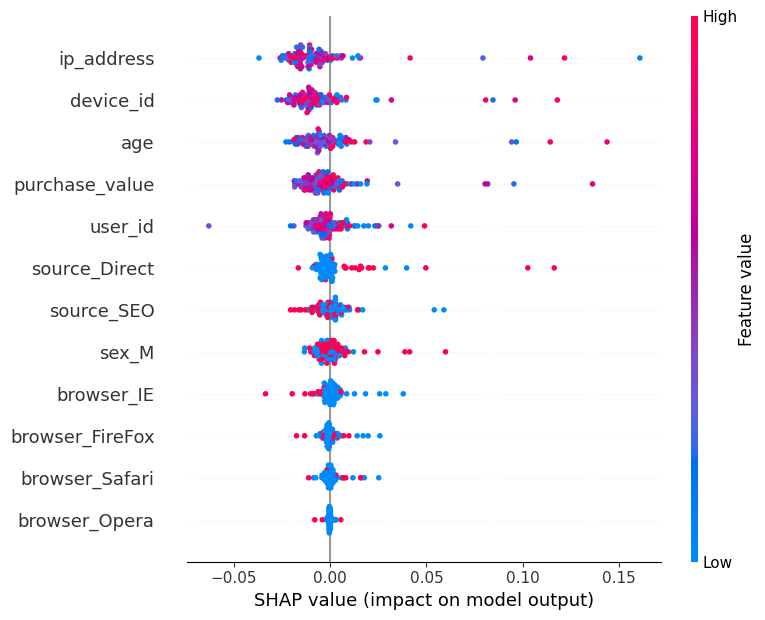

In [98]:
shap.summary_plot(shap_values.values[:, :, 1], X_sample)

In [66]:
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [99]:
y_pred = best_model.predict(X_test)

In [100]:
tp_index = X_test[(y_test == 1) & (y_pred == 1)].index[0]
fp_index = X_test[(y_test == 0) & (y_pred == 1)].index[0]
fn_index = X_test[(y_test == 1) & (y_pred == 0)].index[0]

In [101]:
tp = X_test.loc[[tp_index]]
fp = X_test.loc[[fp_index]]
fn = X_test.loc[[fn_index]]

In [102]:
tp_shap = explainer.shap_values(tp)
fp_shap = explainer.shap_values(fp)
fn_shap = explainer.shap_values(fn)

In [105]:
tp = X_test[(y_test == 1) & (y_pred == 1)].iloc[[0]]

In [106]:
tp_shap = explainer(tp)

In [110]:
y_pred = best_model.predict(X_test)

In [111]:
tp = X_test[(y_test == 1) & (y_pred == 1)].iloc[[0]]
fp = X_test[(y_test == 0) & (y_pred == 1)].iloc[[0]]
fn = X_test[(y_test == 1) & (y_pred == 0)].iloc[[0]]

In [113]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    tp_shap.values[0, :, 1],
    tp
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    fn_shap[0],
    fn
)